In [1]:
from sqlmodel import Session
from theatremix.db import TheatreMixDB
from theatremix import dca

DATABASE = 'mix/blank.tmix'

SCRIPT = 'scripts/12AngryMen.fountain'
with open(SCRIPT) as f:
    text = f.read()

In [2]:
from screenplay_tools.fountain.parser import Parser

p = Parser()
p.add_text(text)
script = p.script
for e in script.elements[:10]:
    print(e.type, e.text)

ElementType.SECTION ACT I
ElementType.NOTE Page 5
ElementType.ACTION The jury room of a New York Court of Law, 1957. A very hot summer afternoon.

It is a large, drab, bare room in need of painting, with three windows in the back wall through which can be seen the New York skyline. Off the jury room is a washroom with wash-basin, soap, and towels (visible on stage) and a lavatory beyond. A large, scarred table is center with twelve chairs around it, A bench stands against the wall and there are several extra chairs and a small table in the room, plus a watercooler, with paper cups and a wastebasket and an electric fan over the bench and a clock above the cooler and row of books for coats, with a shelf over it. There are pencils, pads, and ashtrays on the table. At night the room is lit by fluorescent lighting with the switch next to the door.

When the CURTAIN rises, the room is empty. The voice of the JUDGE is heard.
ElementType.CHARACTER 
ElementType.DIALOGUE ... and that concludes t

In [3]:
# n=p.script.notes[1]
e = p.script.elements[1]
e.notes

dca.generate_dca_cues(p.script, DATABASE)

[Cue(number=1, point=0, name='p5 +Judge\'S Voice: "... and that concludes the cou..."', dca01Channels=None, dca02Channels=None, dca03Channels=None, dca04Channels=None, dca05Channels=None, dca06Channels=None, dca07Channels=None, dca08Channels=None, dca09Channels=None, dca10Channels=None, dca11Channels=None, dca12Channels=None, dca01Label="Judge'S Voice", dca02Label=None, dca03Label=None, dca04Label=None, dca05Label=None, dca06Label=None, dca07Label=None, dca08Label=None, dca09Label=None, dca10Label=None, dca11Label=None, dca12Label=None, channelPositions=None, channelProfiles=None, fxMutes=None, channelFX=None, snippets=None, qLabCue=None, channelLevels=None, scenes=None, colour=None, scenePoints=None),
 Cue(number=2, point=0, name='p6 +Guard -Judge\'S Voice: "All right, let\'s move along, g..."', dca01Channels=None, dca02Channels='13', dca03Channels=None, dca04Channels=None, dca05Channels=None, dca06Channels=None, dca07Channels=None, dca08Channels=None, dca09Channels=None, dca10Channel

In [4]:
from shutil import copy

# cues[:10]

lengths = []


for i in range(100):

    cues = dca.generate_dca_cues(script, DATABASE, max_dialogues_ahead=i)
    lengths.append(len(cues))
    # copy database
    db = f'mix/{i}.tmix'
    copy(DATABASE, db)

    with Session(TheatreMixDB(db).engine) as session:
        session.add_all(cues)
        session.commit()

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
fin

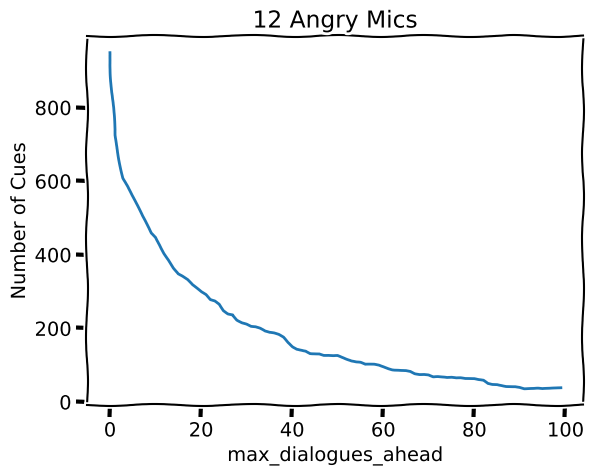

In [5]:
from matplotlib import pyplot as plt

plt.xkcd()

plt.plot(lengths)
plt.title('Number of DCA Cues for different lookahead values')
plt.xlabel('max_dialogues_ahead')
plt.ylabel('Number of Cues')
plt.title('12 Angry Mics')
plt.show()